# ****Libraries****

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

# ****Load and explore the California Housing Dataset. Check shape, info, describe, and null values.****

In [87]:
df = pd.read_csv('housing.csv')

In [88]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


Column Feature:
1. longitude: A measure of how far west a house is; a higher value is farther west
2. latitude: A measure of how far north a house is; a higher value is farther north
3. housingMedianAge: Median age of a house within a block; a lower number is a newer building
4. totalRooms: Total number of rooms within a block
5. totalBedrooms: Total number of bedrooms within a block
6. population: Total number of people residing within a block
7. households: Total number of households, a group of people residing within a home unit, for a block
8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)
9. medianHouseValue: Median house value for households within a block (measured in US Dollars)
10. oceanProximity: Location of the house w.r.t ocean/sea

In [89]:
df.shape

(20640, 10)

In [90]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [91]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

# ****Visualize feature correlations using a heatmap. Identify the top 3 features most correlated with price.****

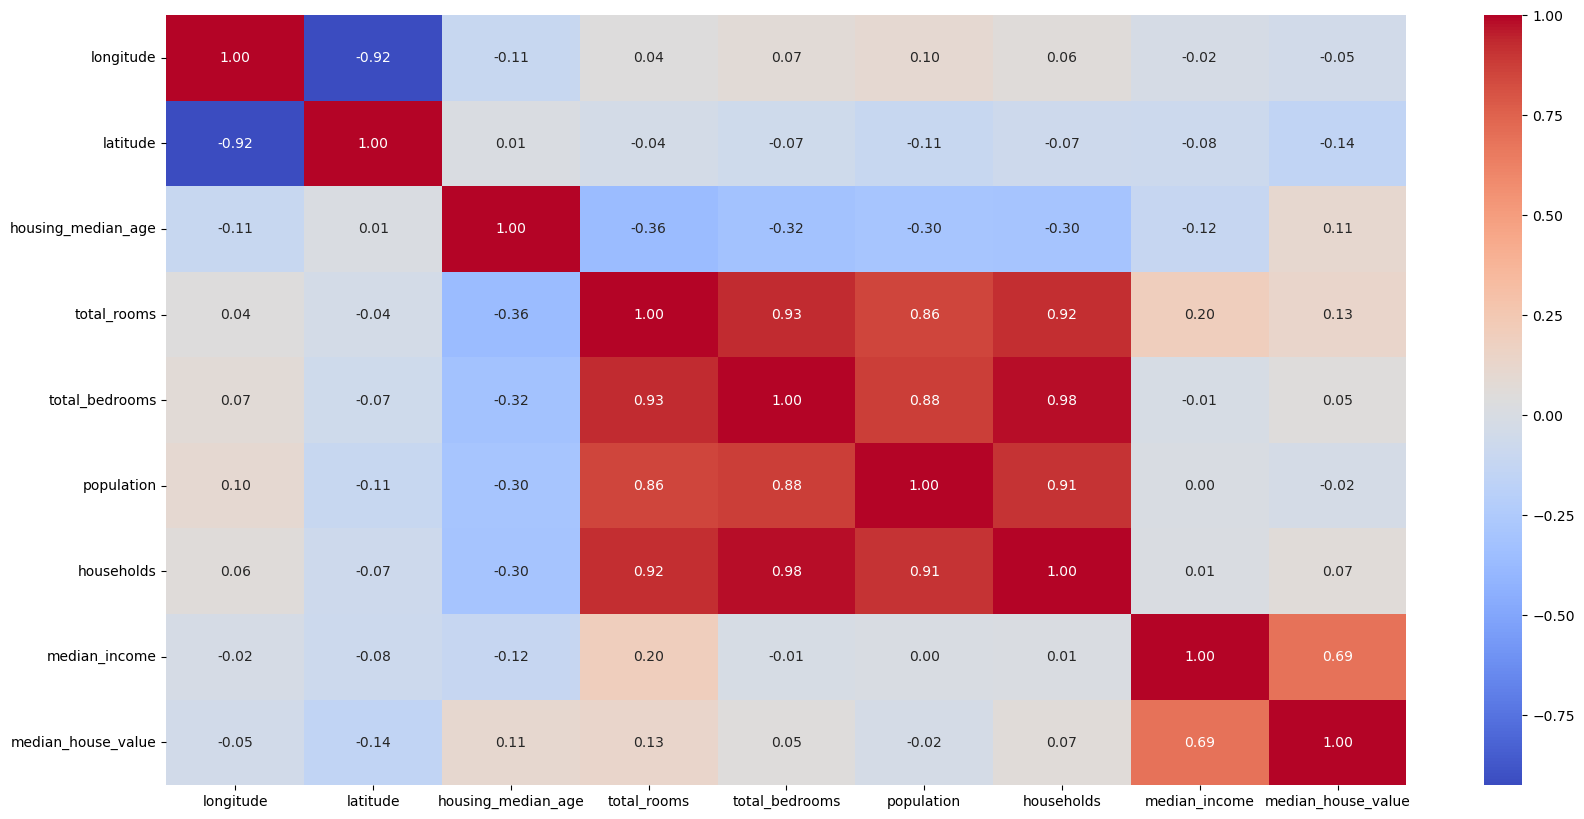

In [ ]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(20,10))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

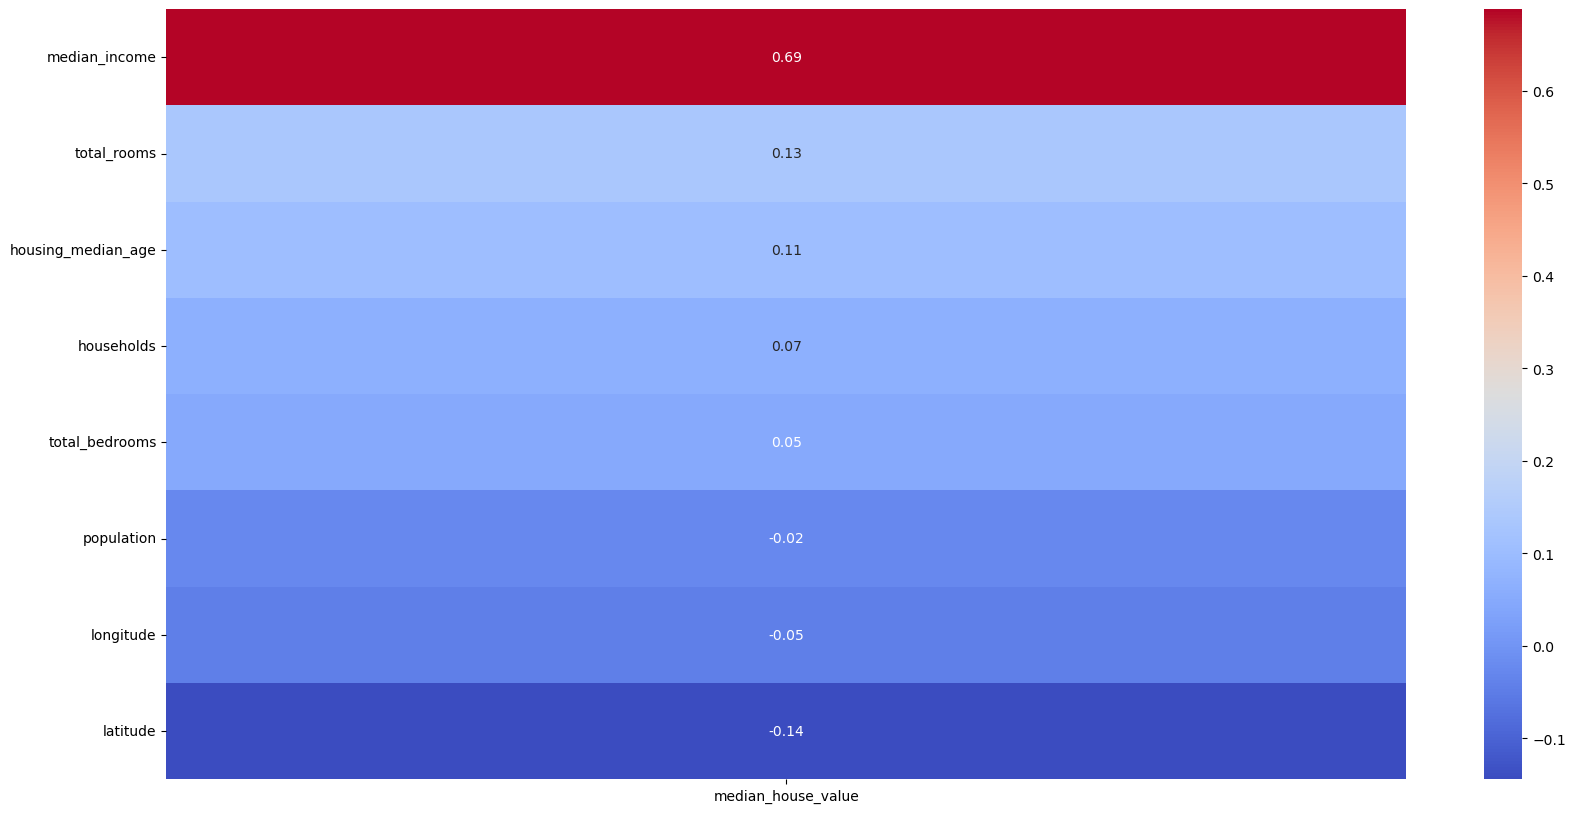

In [93]:
correlation = df.corr(numeric_only=True)[['median_house_value']].sort_values(by='median_house_value', ascending=False).drop('median_house_value', axis=0)
plt.figure(figsize=(20,10))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

### Top 3 Features:
### 1. median_income
### 2. total_rooms
### 3. housing_median_age

# ****Preprocess: handle missing values and scale numerical features using StandardScaler.****

In [94]:
df.total_bedrooms.value_counts(dropna=False)

total_bedrooms
NaN       207
280.0      55
331.0      51
345.0      50
343.0      49
         ... 
2009.0      1
2249.0      1
3114.0      1
1625.0      1
1742.0      1
Name: count, Length: 1924, dtype: int64

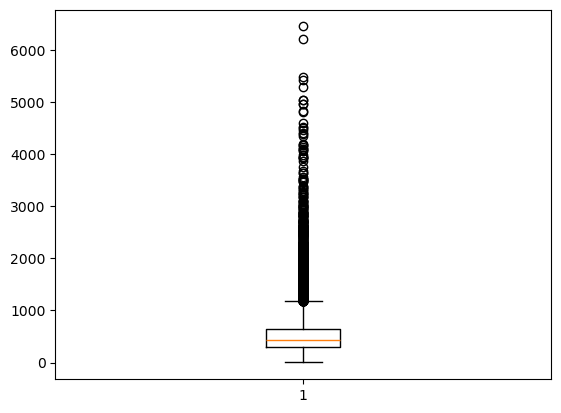

In [95]:
plt.boxplot(df['total_bedrooms'].dropna())
plt.show()

### Since total_bedrooms have no correlation with any feature and has many outliers. Therefore, we can impute missing values using ****median****

In [96]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [97]:
df['total_bedrooms'].value_counts()

total_bedrooms
435.0     244
280.0      55
331.0      51
345.0      50
393.0      49
         ... 
2009.0      1
2249.0      1
3114.0      1
1625.0      1
1742.0      1
Name: count, Length: 1923, dtype: int64

In [98]:
df['total_bedrooms'].isnull().sum()

np.int64(0)

In [99]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [100]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [101]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [102]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True, dtype=int)

In [103]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1,0,0,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1,0,0,0


In [104]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [105]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [106]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train, y_train)
X_test_scaled = scaler.transform(X_test)

# ****Split data into 80% training and 20% testing sets****

### Already Done!

# ****Train a Linear Regression model. Evaluate using MAE, MSE, and R² score****

In [107]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [108]:
train_predict_lr = model_lr.predict(X_train_scaled)
test_predict_lr = model_lr.predict(X_test_scaled)

In [109]:
mae_train_lr = mean_absolute_error(y_train, train_predict_lr)
mae_test_lr = mean_absolute_error(y_test, test_predict_lr)
mse_train_lr = mean_squared_error(y_train, train_predict_lr)
mse_test_lr = mean_squared_error(y_test, test_predict_lr)
r2_train_lr = r2_score(y_train, train_predict_lr)
r2_test_lr = r2_score(y_test, test_predict_lr)

In [110]:
model_lr_performance = pd.DataFrame({
    'Model': 'Linear Regression',
    'MAE Train': [mae_train_lr],
    'MAE Test': [mae_test_lr],
    'MSE Train': [mse_train_lr],
    'MSE Test': [mse_test_lr],
    'R2 Train': [r2_train_lr],
    'R2 Test': [r2_test_lr]
})
model_lr_performance = model_lr_performance.set_index('Model')
model_lr_performance

,MAE Train,MAE Test,MSE Train,MSE Test,R2 Train,R2 Test
Model,,,,,,
Linear Regression,49594.842095,50670.738241,4.683204e+09,4.908477e+09,0.649665,0.625424


# ****Train a Decision Tree Regressor. Tune max_depth (try 3, 5, 10) and report best results.****

In [111]:
parameter_grid = {
    'max_depth' : [3, 5, 10]
}
grid_search = GridSearchCV(estimator=DecisionTreeRegressor(), param_grid=parameter_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'max_depth': [3, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


### Best Result: max_depth=10

In [112]:
model_dtr = grid_search.best_estimator_
model_dtr.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [113]:
train_predict_dtr = model_dtr.predict(X_train)
test_predict_dtr = model_dtr.predict(X_test)

In [114]:
mae_train_dtr = mean_absolute_error(y_train, train_predict_dtr)
mae_test_dtr = mean_absolute_error(y_test, test_predict_dtr)
mse_train_dtr = mean_squared_error(y_train, train_predict_dtr)
mse_test_dtr = mean_squared_error(y_test, test_predict_dtr)
r2_train_dtr = r2_score(y_train, train_predict_dtr)
r2_test_dtr = r2_score(y_test, test_predict_dtr)

In [115]:
model_dtr_performance = pd.DataFrame({
    'Model': 'Decision Tree Regressor',
    'MAE Train': [mae_train_dtr],
    'MAE Test': [mae_test_dtr],
    'MSE Train': [mse_train_dtr],
    'MSE Test': [mse_test_dtr],
    'R2 Train': [r2_train_dtr],
    'R2 Test': [r2_test_dtr]
})
model_dtr_performance = model_dtr_performance.set_index('Model')
model_dtr_performance

,MAE Train,MAE Test,MSE Train,MSE Test,R2 Train,R2 Test
Model,,,,,,
Decision Tree Regressor,32927.106579,40611.349214,2.361391e+09,3.751867e+09,0.823352,0.713687


# ****Plot Actual vs Predicted values for both models.****

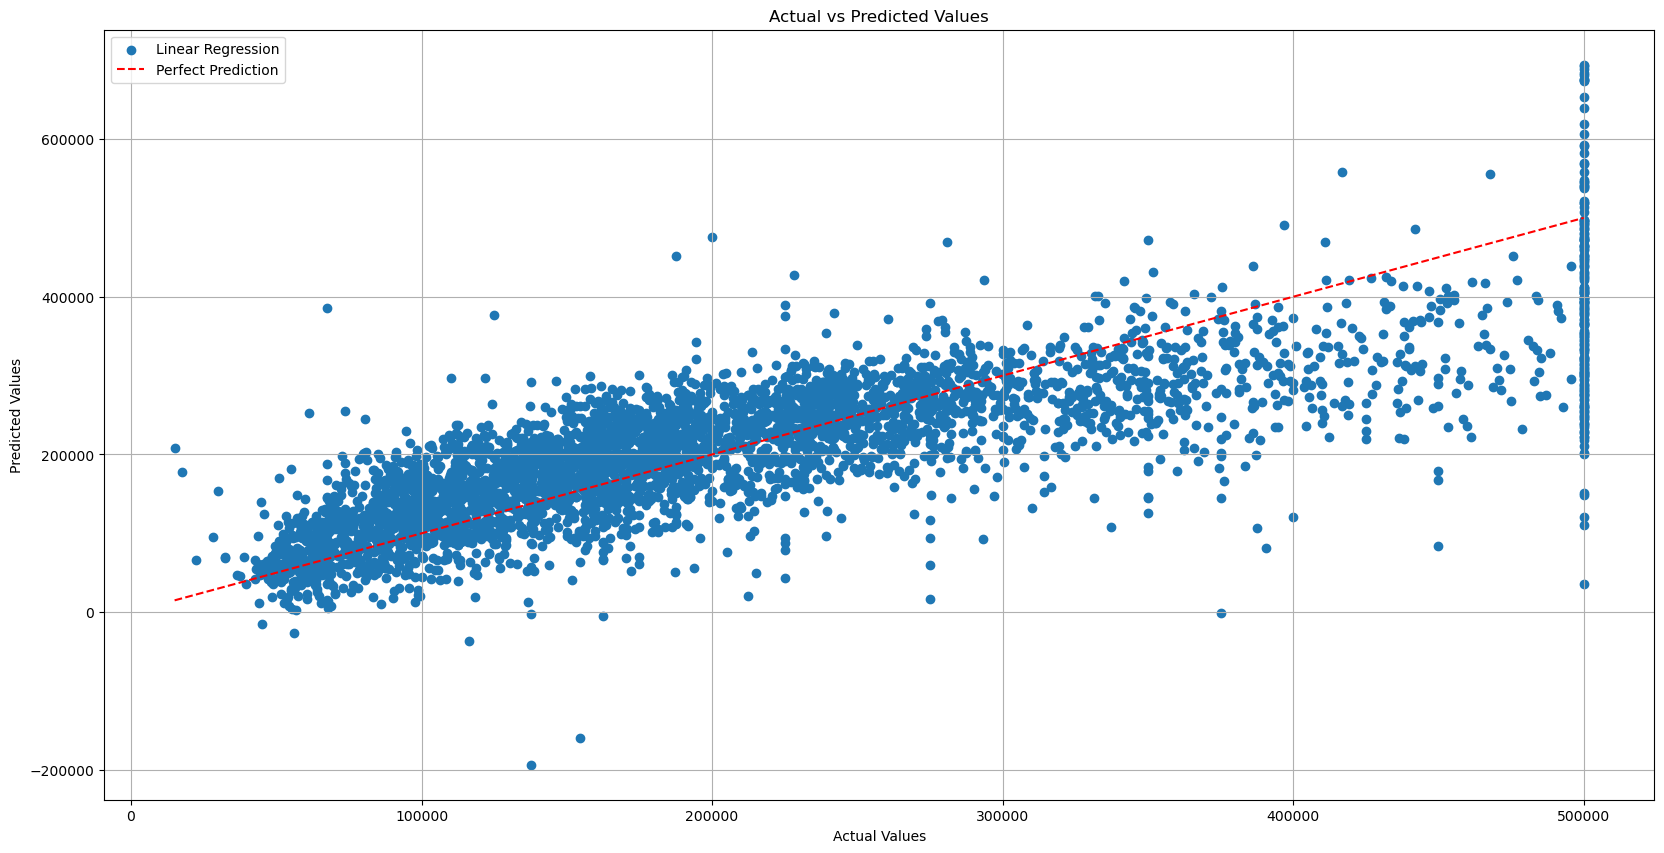

In [116]:
plt.figure(figsize=(20,10))
plt.scatter(y_test, test_predict_lr, label='Linear Regression')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.grid()
plt.show()

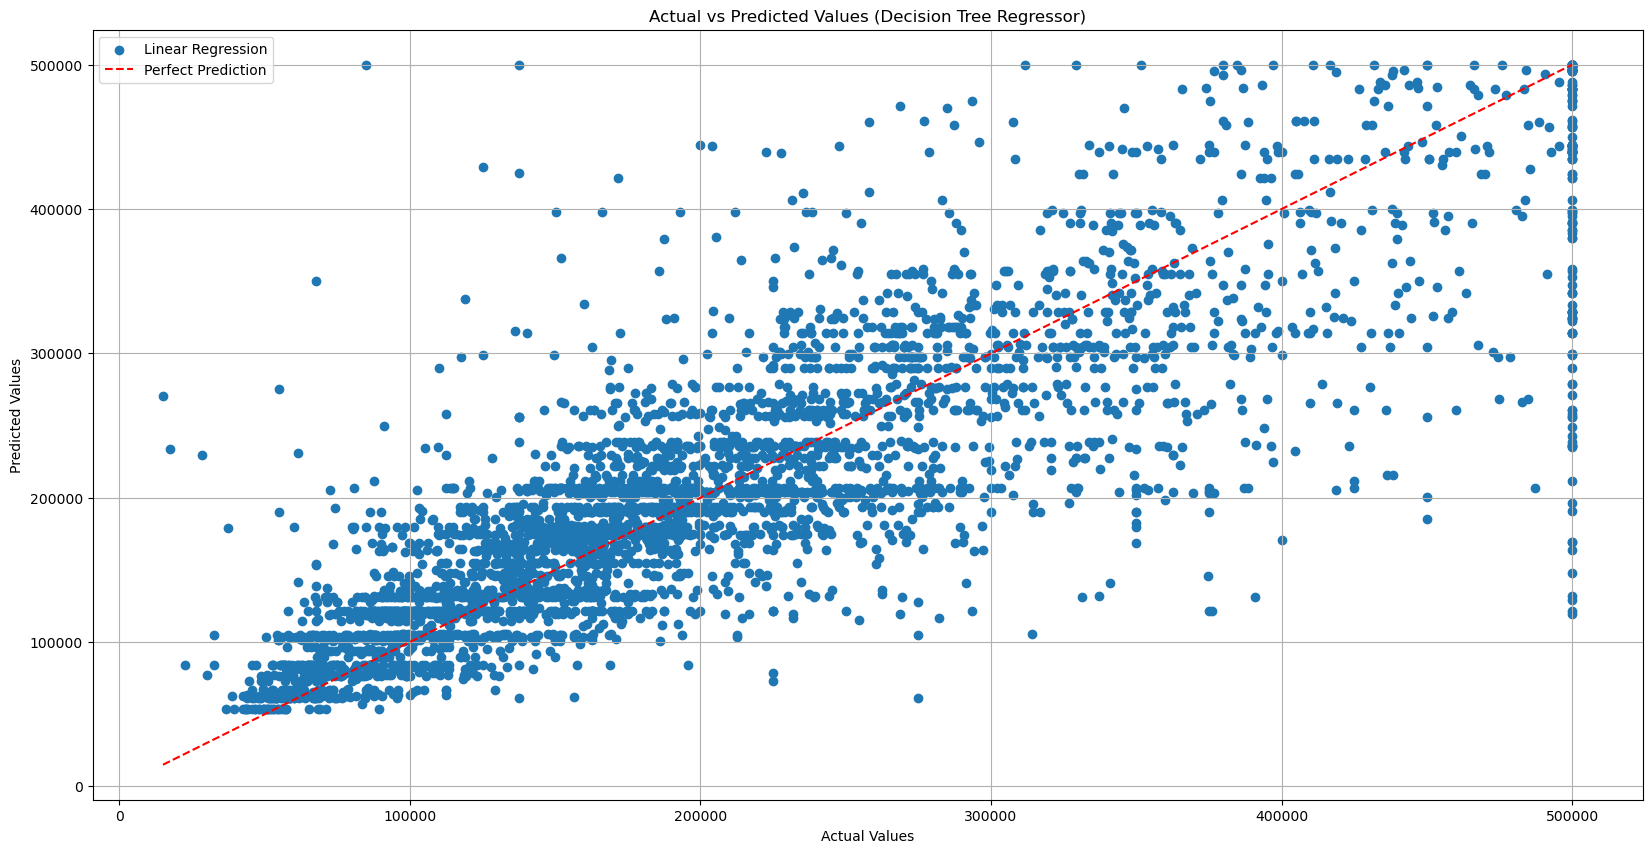

In [117]:
plt.figure(figsize=(20,10))
plt.scatter(y_test, test_predict_dtr, label='Linear Regression')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Decision Tree Regressor)")
plt.legend()
plt.grid()
plt.show()

# ****Compare both models in a summary table and write a short conclusion on which performed better and why.****

In [118]:
model_performance = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree Regressor'],
    'MAE Train': [mae_train_lr, mae_train_dtr],
    'MAE Test': [mae_test_lr, mae_test_dtr],
    'MSE Train': [mse_train_lr, mse_train_dtr],
    'MSE Test': [mse_test_lr, mse_test_dtr],
    'R2 Train': [r2_train_lr, r2_train_dtr],
    'R2 Test': [r2_test_lr, r2_test_dtr]
})
model_performance = model_performance.set_index('Model')
model_performance

,MAE Train,MAE Test,MSE Train,MSE Test,R2 Train,R2 Test
Model,,,,,,
Linear Regression,49594.842095,50670.738241,4.683204e+09,4.908477e+09,0.649665,0.625424
Decision Tree Regressor,32927.106579,40611.349214,2.361391e+09,3.751867e+09,0.823352,0.713687


<div style="font-family:Arial, sans-serif; max-width:900px; margin:auto; border:2px solid #2c3e50; border-radius:10px; overflow:hidden;">

<div style="background:#2c3e50; color:white; padding:20px; text-align:center;">
<h1>Housing Price Prediction Summary Report</h1>
</div>
<div style="padding:20px;">


## Key Findings

#### - Decision Tree acheived better performance than Linear Regression
#### - Linear Regression underperformed due to assuming that the features in dataset has linear relationship.
#### - Decision Tree captured performed well but learning non-linear relationship in the dataset
#### - Tree-based models usually perform better in non-linear relationship in the dataset.

---

## Conclusion

#### Among the implemented models, **Decision Tree Regressor** performed better than **Linear Regression** because it effectively captured non-linear relationships within the dataset.
</div>